In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[1], 'GPU')

import hmc
import func

In [3]:
sig_np = lambda x: np.tanh(2*x) - 0.7294775*x
sig = lambda x: tf.nn.tanh(2*x) - 0.7294775*x
g, dg, l_e, m_e, l_s, m_s = func.sig_related(sig_np)

In [4]:
d = 200
gamma = 0.5
Delta = 0.01

alpha = 0.4
k = int(gamma*d)
n = int(alpha*d**2)

beta = 0.8
v_np = func.v_generate(k, beta)
v = tf.constant(v_np, dtype=tf.float32)
mmse_theory, qw_theory = func.solve(n, d, Delta, v_np, g, m_e)
kc = np.argmin(qw_theory>0) # number of learned features

params = {'step_size': 0.01,
          'num_leapfrog_steps': 10,
          'num_adaptation_steps': 2000
         }

W0, X, Y = hmc.data_generate(d, k, n, Delta, sig, v) # train dataset
ntest = 40000
Xtest = tf.random.normal((d, ntest), dtype=tf.float32) # testset


I0000 00:00:1778873832.286291  837459 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13467 MB memory:  -> device: 1, name: NVIDIA RTX A4000, pci bus id: 0000:65:00.0, compute capability: 8.6


In [5]:
W_init = W0[:kc, :] # student init
Delta_ = Delta + g(1)*np.sum([v**2 for v in v[kc:]])
v_ = v[:kc]

Ws = hmc.hmc(params, W_init, v_, X, Y, Delta_, sig)

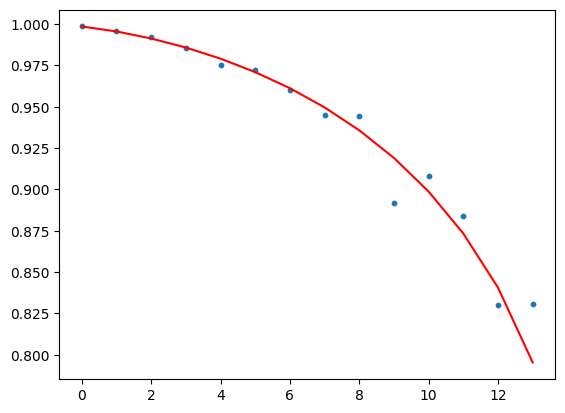

In [6]:
Wf = Ws[-1]
aligns = [func.align(Wf[i], W0[i]) for i in range(kc)]
plt.scatter(np.arange(kc), aligns, s=10)
plt.plot(qw_theory[:kc], color='red')
plt.show()